In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pynamicalsys import DiscreteDynamicalSystem as dds
from joblib import Parallel, delayed

# Standard map

## Enter exit regions

In [26]:
ds = dds(model="standard map")
ds.set_parameters(1.5)
centers = [[0.05, 0.05], [0.9, 0.9]]
hole_size = 0.05
N = 100000

In [28]:
u = np.array([0.12, 0.5])
ds.escape_analysis(u, N, centers, hole_size=hole_size)

(0, 133)

In [29]:
xlims = (0, 1)
ylims = (0, 1)
grid = 540
x = np.linspace(xlims[0], xlims[1], grid)
y = np.linspace(ylims[0], ylims[1], grid)
X, Y = np.meshgrid(x, y)

In [31]:
escape = np.array(Parallel(n_jobs=-1)(delayed(ds.escape_analysis)(np.array([X[i, j], Y[i, j]]), N, centers, hole_size=hole_size) for i in range(grid) for j in range(grid)))

In [32]:
escape[:, 0].shape

(291600,)

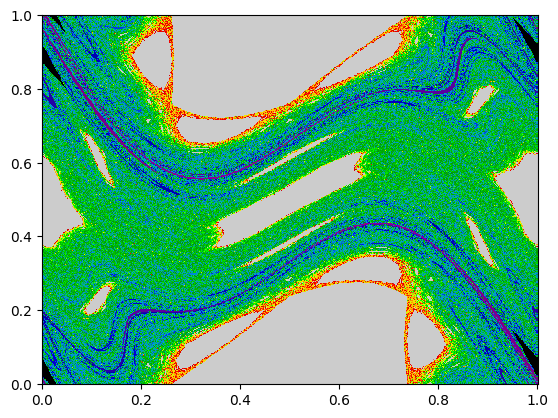

In [33]:
plt.pcolor(X, Y, escape[:, 1].reshape(grid, grid), cmap="nipy_spectral", norm=mpl.colors.LogNorm(vmin=1, vmax=N))

In [34]:
from matplotlib.colors import ListedColormap, BoundaryNorm

In [35]:
escape[:, 0].min()

np.int64(-1)

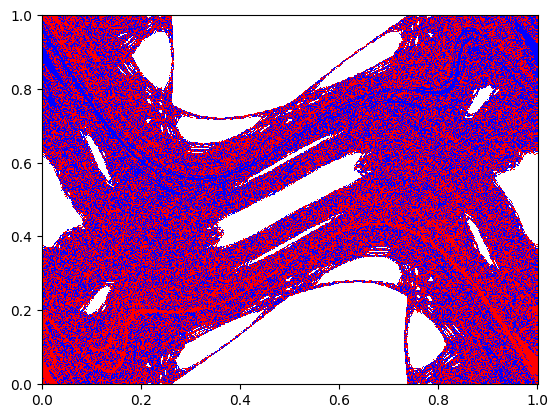

In [36]:
colors = ["white", "red", "blue"]
cmap = ListedColormap(colors)  # 0 → blue, 1 → green, 2 → red
bounds = [-1, 0, 1, 2]  # edges between categories
norm = BoundaryNorm(bounds, cmap.N)

plt.pcolor(X, Y, escape[:, 0].reshape(grid, grid), cmap=cmap, norm=norm)

In [37]:
times, sp = ds.survival_probability(escape[:, 1], N)

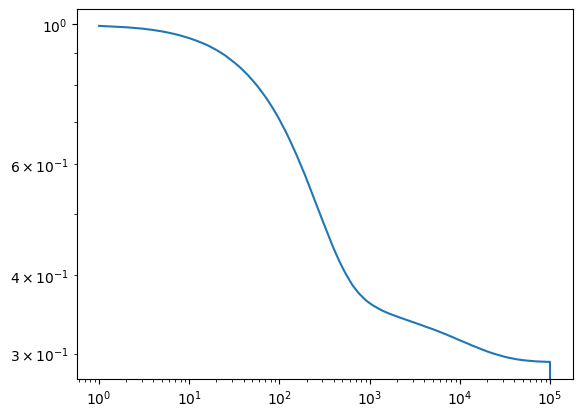

In [38]:
plt.plot(times, sp)
plt.xscale("log")
plt.yscale("log")

# Henon map

In [13]:
henon = dds(model="henon map")

In [14]:
parameters = np.array([1.5, 0.3])
henon.set_parameters(parameters)
exists = np.array([[-10, 10], [-10, 10]], dtype=np.float64)
N = 10000
grid_size = 540
x_range = (-3, 3)
y_range = (-3, 3)
x = np.linspace(x_range[0], x_range[1], grid_size)
y = np.linspace(y_range[0], y_range[1], grid_size)
X, Y = np.meshgrid(x, y)

In [15]:
escape = np.array(Parallel(n_jobs=-1)(delayed(henon.escape_analysis)(np.array([X[i, j], Y[i, j]]), N, exists, escape="exiting") for i in range(grid_size) for j in range(grid_size)))

In [16]:
escape

array([[0, 1],
       [0, 1],
       [0, 1],
       ...,
       [0, 2],
       [0, 2],
       [0, 2]], shape=(291600, 2))

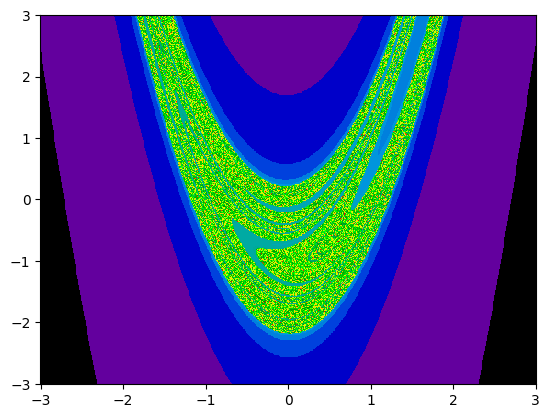

In [17]:
plt.pcolor(X, Y, escape[:, 1].reshape(grid_size, grid_size), cmap="nipy_spectral", norm=mpl.colors.LogNorm(vmin=1, vmax=escape.max()))

In [18]:
type(escape[:, 1].max()), isinstance(escape[:, 1].max(), np.int32)

(numpy.int64, False)

In [19]:
escape_arr = np.asarray(escape[:, 1], dtype=int)

In [20]:
type(escape_arr.max()), isinstance(escape_arr.max(), int)

(numpy.int64, False)

In [21]:
type(escape[:, 1].max())

numpy.int64

In [22]:
sp = henon.survival_probability(escape[:, 1], escape[:, 1].max())

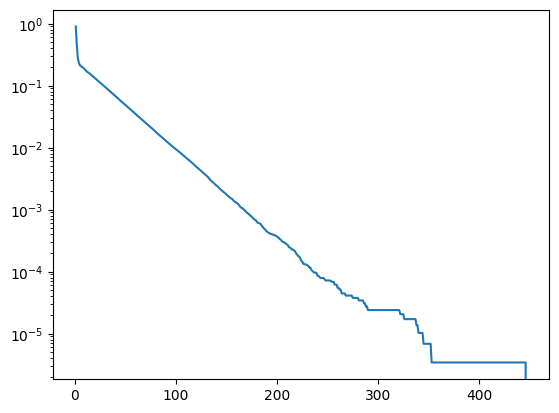

In [23]:
plt.plot(sp[0], sp[1])
#plt.xscale("log")
plt.yscale("log")